# SIGReg

Sliced Epps–Pulley regularizer toward `N(0, I)` from [LeJEPA](https://arxiv.org/abs/2511.08544).


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import matplotlib.pyplot as plt
from pytorch_katas import SIGReg

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
crit = SIGReg(num_slices=512).to(device)
print(crit)

SIGReg()


## Scores


isotropic        1.1620
collapse      2153.8657
rank-1         326.2311
shifted       2075.0806
anisotropic   1007.8620


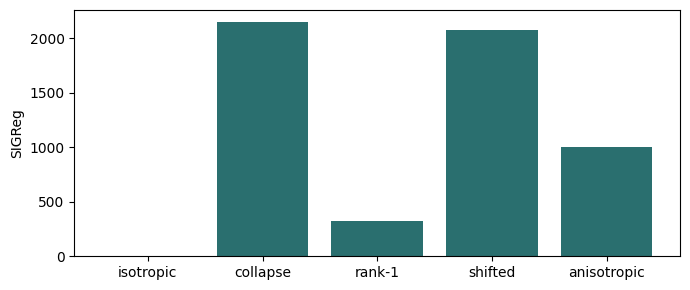

In [3]:
N, D = 2048, 32
cases = {
    "isotropic": torch.randn(N, D, device=device),
    "collapse": torch.ones(N, D, device=device),
    "rank-1": torch.randn(N, 1, device=device) @ torch.randn(1, D, device=device),
    "shifted": torch.randn(N, D, device=device) + 2,
    "anisotropic": torch.randn(N, D, device=device) * torch.linspace(0.2, 5, D, device=device),
}
scores = {k: crit(v).item() for k, v in cases.items()}
for k, v in scores.items():
    print(f"{k:12s} {v:10.4f}")
plt.figure(figsize=(7, 3))
plt.bar(scores.keys(), scores.values(), color="#2a6f6f")
plt.ylabel("SIGReg"); plt.tight_layout(); plt.show()

## Whiten with SIGReg alone


final=2.1206 mean_norm=0.0829


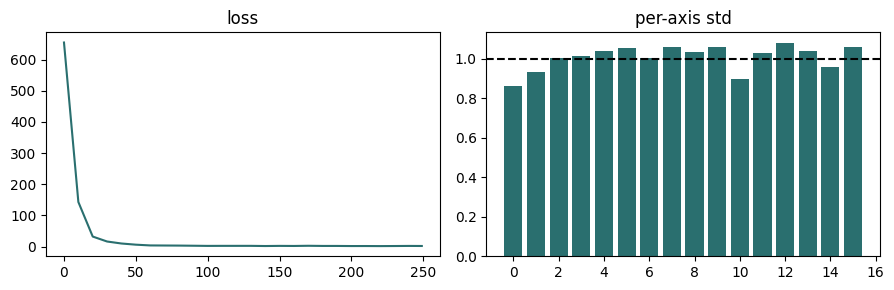

In [4]:
torch.manual_seed(1)
X = torch.randn(1024, 16, device=device)
X = X * torch.linspace(0.2, 5, 16, device=device) + 1.5
W = torch.nn.Parameter(torch.eye(16, device=device))
b = torch.nn.Parameter(torch.zeros(16, device=device))
opt = torch.optim.Adam([W, b], lr=5e-2)
curve = []
for step in range(250):
    loss = crit(X @ W + b)
    opt.zero_grad(); loss.backward(); opt.step()
    if step % 10 == 0 or step == 249:
        curve.append((step, loss.item()))
steps, vals = zip(*curve)
Z = (X @ W + b).detach()
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].plot(steps, vals, color="#2a6f6f"); ax[0].set_title("loss")
ax[1].bar(range(16), Z.std(0).cpu(), color="#2a6f6f"); ax[1].axhline(1, c="k", ls="--")
ax[1].set_title("per-axis std")
print(f"final={vals[-1]:.4f} mean_norm={Z.mean(0).norm():.4f}")
fig.tight_layout(); plt.show()